# Análise de dados de Sistema de Monitoramento

O presente trabalho tem como objetivo analisar os dados das avaliações Somativas aplicadas à parte das turmas do programa PBA Sergipe para entender a eficácia pedagógica do programa através de seus instrumentos. Serão analisadas somente 35 turmas que tiverem início posterior ao das demais turmas regulares. As turmas a serem estudadas são as seguintes:

TURMA-P0000123-0001; 
TURMA-P0000122-0001; 
TURMA-P0000122-0002; 
TURMA-28009398-0017; 
TURMA-28010450-0006; 
TURMA-28032730-0006; 
TURMA-28018575-0016; 
TURMA-28023315-0007; 
TURMA-28023315-0008; 
TURMA-28023315-0009; 
TURMA-28020766-0004; 
TURMA-28020766-0012; 
TURMA-28020472-0005; 
TURMA-28020472-0006; 
TURMA-28011058-0008; 
TURMA-28005201-0006; 
TURMA-28006569-0004; 
TURMA-28006569-0005; 
TURMA-28020529-0004; 
TURMA-28020529-0005; 
TURMA-28028562-0006; 
TURMA-28003551-0007; 
TURMA-28020421-0004; 
TURMA-28010434-0001; 
TURMA-28026667-0028; 
TURMA-28026667-0029; 
TURMA-28026667-0030; 
TURMA-28026667-0031; 
TURMA-28026667-0032; 
TURMA-28026667-0033; 
TURMA-28026667-0034; 
TURMA-28020804-0003; 
TURMA-28009576-0001; 
TURMA-28006950-0005; 
TURMA-28009983-0005.

## Importando bibliotecas e dados

In [1]:
# Importando bibliotecas
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pandas as pd
import numpy as np
import textwrap
from scipy.stats import chi2_contingency, wilcoxon

# Importando arquivo
df_cadastro = pd.read_excel(
    'Data_files/public_data/xls_pedagogico_02122025.xlsx')
df_turmas = pd.read_excel(
    'Data_files/public_data/turmas_02122025.xlsx')
df_registros = pd.read_excel(
    'Data_files/public_data/xls_detalhado_02122025.xlsx')
df_relatorios_diagnostica = pd.read_excel(
    'Data_files/public_data/relatorios_turmas_diagnostica_02122025.xlsx')
df_relatorios_formativa1 = pd.read_excel(
    'Data_files/public_data/relatorios_turmas_formativa1_02122025.xlsx')
df_relatorios_formativa2 = pd.read_excel(
    'Data_files/public_data/relatorios_turmas_formativa2_02122025.xlsx')
df_relatorios_formativa3 = pd.read_excel(
    'Data_files/public_data/relatorios_turmas_formativa3_02122025.xlsx')
df_relatorios_formativa4 = pd.read_excel(
    'Data_files/public_data/relatorios_turmas_formativa4_02122025.xlsx')
df_relatorios_somativa = pd.read_excel(
    'Data_files/public_data/relatorios_turmas_somativa_02122025.xlsx')

print('df_cadastro:')
print(df_cadastro.info())
#print(df_cadastro.head())

print('df_turmas:')
print(df_turmas.info())
#print(df_turmas.head())

print('df_registros:')
print(df_registros.info())
#print(df_registros.head())

print('df_relatorios_diagnostica:')
print(df_relatorios_diagnostica.info())
#print(df_relatorios_diagnostica.head())

print('df_relatorios_formativa1:')
print(df_relatorios_formativa1.info())
#print(df_relatorios_formativa1.head())

print('df_relatorios_formativa2:')
print(df_relatorios_formativa2.info())
#print(df_relatorios_formativa2.head())

print('df_relatorios_formativa3:')
print(df_relatorios_formativa3.info())
#print(df_relatorios_formativa3.head())

print('df_relatorios_formativa4:')
print(df_relatorios_formativa4.info())
#print(df_relatorios_formativa4.head())

print('df_relatorios_somativa:')
print(df_relatorios_somativa.info())
#print(df_relatorios_somativa.head())


df_cadastro:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4580 entries, 0 to 4579
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   CPF                        4580 non-null   object
 1   Nome                       4580 non-null   object
 2   Turma                      4580 non-null   object
 3   Data de início             4580 non-null   object
 4   Alfabetizador              4580 non-null   object
 5   Coordenador                4580 non-null   object
 6   Qtde presença              4580 non-null   int64 
 7   Qtde ausência              4580 non-null   int64 
 8   Atividade - Entrada        4574 non-null   object
 9   Atividade - Formativa 1    4574 non-null   object
 10  Atividade - Formativa 2    4580 non-null   object
 11  Atividade - Formativa 3    4580 non-null   object
 12  Atividade - Formativa 4    4555 non-null   object
 13  Atividade - Saída          4543 non-null   object


## Tratando dos dados
Se faz necessário a transformação dos dados para que seja mais fácil sua análise. De acordo com a observação dos dados apresentados, as seguintes transformações serão necessárias:
Em df_registros:
- Transformar nomes de cada coluna para o padrão snake_case;
- Extrair somente os níveis da coluna "Nível";
- Deixar os níveis de maneira categórica corretamente para melhor análise na coluna "Nível".

Em df_relatorios
- Transformar nomes de cada coluna para o padrão snake_case;
- As colunas que contém perguntas serão reduzidas somente a palavra "pergunta" seguida do seu número, exemplo: pergunta_1
- As categorias de resposta serão resumidas em no máximo 3 palavras para facilitar a interpretação - um dicionário será criado aqui.

Em df_cadastro, df_turmas, df_relatorios_(diagnostica / formativa1, 2 e 3):
- Todas as colunas que contem datas deverão ser tranformados para o tipo datetime.

In [2]:
# Transformando nomes de colunas para padrão snake_case
# Função para converter para snake_case
def to_snake_case(column_name):
    return (
        column_name
        .lower()  # Converte tudo para minúsculo
        .replace(' ', '_')  # Substitui espaços por underscore
        .replace('é', 'e')  # Remove acentos
        .replace('ã', 'a')
        .replace('ç', 'c')
        .replace('í', 'i')
        .replace('ó', 'o')
        .replace('ú', 'u')
        .replace('á', 'a')
    )

# Função para extrair o número de perguntas e renomear
def renomear_perguntas(nome_coluna):
    match = re.match(r'^(\d+)\._', nome_coluna)  # Procura o padrão "X._" no início
    if match:
        numero = match.group(1)
        return f'pergunta_{numero}'
    return nome_coluna  # Mantém o nome original se não for uma pergunta numerada

# Aplica a função to_snake_case aos nomes das colunas
df_cadastro.columns = [to_snake_case(col) for col in df_cadastro.columns]
df_turmas.columns = [to_snake_case(col) for col in df_turmas.columns]
df_registros.columns = [to_snake_case(col) for col in df_registros.columns]
df_relatorios_diagnostica.columns = [to_snake_case(col) for col in df_relatorios_diagnostica.columns]
df_relatorios_formativa1.columns = [to_snake_case(col) for col in df_relatorios_formativa1.columns]
df_relatorios_formativa2.columns = [to_snake_case(col) for col in df_relatorios_formativa2.columns]
df_relatorios_formativa3.columns = [to_snake_case(col) for col in df_relatorios_formativa3.columns]
df_relatorios_formativa4.columns = [to_snake_case(col) for col in df_relatorios_formativa4.columns]
df_relatorios_somativa.columns = [to_snake_case(col) for col in df_relatorios_somativa.columns]

# Aplica a função renomear_perguntas a todas as colunas
df_relatorios_diagnostica.columns = [renomear_perguntas(col) for col in df_relatorios_diagnostica.columns]
df_relatorios_somativa.columns = [renomear_perguntas(col) for col in df_relatorios_somativa.columns]

# Extraindo somente os dados de nível em df_registros
df_registros['nivel'] = df_registros['nivel'].str.extract(r'(Nível [1-3])')

# Ordenando nívels de maneira categórica corretamente
df_registros['nivel'] = pd.Categorical(
    df_registros['nivel'],
    categories=['Nível 1', 'Nível 2', 'Nível 3'],
    ordered=True)

# Verificando os tipos de dados e informações das colunas
#print(df_cadastro.info())
#print(df_turmas.info())
#print(df_registros.info())
#print(df_relatorios_diagnostica.info())


In [3]:
# Tratando dados dos relatórios de Somativa
# Mapeando as perguntas e respostas
mapeamento_respostas = {
    'pergunta_1': {
        'Alto interesse, aplicou com frequência no cotidiano.': 'Alto interesse', 
        'Interesse moderado, aplicou ocasionalmente no cotidiano.': 'Interesse moderado',
        'Baixo interesse, raramente aplicou o aprendizado.':'Baixo interesse'
    }, 
    'pergunta_2': {
        'Total autonomia e responsabilidade, sendo pontual e organizado.': 'Total autonomia',
        'Autonomia em alguns aspectos, mas com lapsos de organização.': 'Autonomia parcial',
        'Precisou de apoio constante para se organizar e manter a responsabilidade.': 'Precisou de apoio'
    },
    'pergunta_3': {
        'Demonstraram alguma insegurança, mas conseguiram superá-las com apoio.': 'Alguma insegurança',
        'Enfrentaram bem as inseguranças e participaram ativamente.': 'Enfrentaram bem',
        'Com grande resiliência, não desistiram diante de dificuldades.': 'Muita insegurança\ne resiliência'
    },
    'pergunta_4': {
        'Com grande resiliência, não desistiram diante de dificuldades.': 'Com grande resiliência',
        'Participando ativamente, interagindo bem e contribuindo com o grupo.': 'Participando ativamente',
        'Com resiliência moderada, desanimando em situações difíceis.': 'Com resiliência moderada'
    },
    'pergunta_5': {
        'Participando ativamente, interagindo bem e contribuindo com o grupo.': 'Participação ativa',
        'Progresso moderado, mas com algumas dificuldades ainda presentes.': 'Participação moderada',
        'Participando de forma moderada, com pouca interação.': 'Participação mínima'
    },
    'pergunta_6': {
        'Significativamente o reconhecimento de palavras e compreensão de textos.': 'Progresso significativo',
        'Frequentemente o que aprendeu em situações práticas do cotidiano.': 'Progresso reduzido',
        'Progresso moderado, mas com algumas dificuldades ainda presentes.': 'Progresso moderado'
    },
    'pergunta_7': {
        'Frequentemente o que aprendeu em situações práticas do cotidiano.': 'Frequentemente',
        'Reconhecer claramente suas conquistas, apresentando satisfação com o aprendizado.': 'Raramente',
        'Ocasionalmente o que aprendeu em algumas situações cotidianas.': 'Ocasionalmente'
    },
    'pergunta_8': {
        'Reconhecer claramente suas conquistas, apresentando satisfação com o aprendizado.': 'Reconhecer claramente',
        'Nível 2: evidência de aprendizagem em processo.': 'Dificuldade em reconhecer',
        'Reconhecer parcialmente suas conquistas, mas sem grande celebração.': 'Reconhecer parcialmente'
    },
    'pergunta_9': {
        'Nível 3: evidência de aprendizagem consolidada.': 'Nível 3',
        'Nível 2: evidência de aprendizagem em processo.': 'Nível 2',
        'Nível 1: evidência de aprendizagem não consolidada.': 'Nível 1'
    }
}

# Aplicar o mapeamento
for pergunta, mapeamento in mapeamento_respostas.items():
    if pergunta in df_relatorios_somativa.columns:
        df_relatorios_somativa[pergunta] = df_relatorios_somativa[pergunta].replace(mapeamento)


In [4]:
# Retirando coluna do dataframe df_relatorios_somativa
df_relatorios_somativa = df_relatorios_somativa.drop(df_relatorios_somativa.columns[-1], axis=1)

# Imprimindo resultado
print(df_relatorios_somativa.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 328 entries, 0 to 327
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   alfabetizador       328 non-null    object
 1   turma               328 non-null    object
 2   data_de_lancamento  328 non-null    object
 3   pergunta_1          328 non-null    object
 4   pergunta_2          328 non-null    object
 5   pergunta_3          328 non-null    object
 6   pergunta_4          328 non-null    object
 7   pergunta_5          328 non-null    object
 8   pergunta_6          328 non-null    object
 9   pergunta_7          328 non-null    object
 10  pergunta_8          328 non-null    object
 11  pergunta_9          323 non-null    object
dtypes: object(12)
memory usage: 30.9+ KB
None


### Extração das 35 turmas a serem analisadas
Antes de iniciar as análises, vamos extrair somente os dados das 35 turmas que precisamos e descartar todo o resto.

In [5]:
# Lista das turmas que você quer filtrar
turmas_selecionadas = [
    "TURMA-P0000123-0001", "TURMA-P0000122-0001", "TURMA-P0000122-0002",
    "TURMA-28009398-0017", "TURMA-28010450-0006", "TURMA-28032730-0006",
    "TURMA-28018575-0016", "TURMA-28023315-0007", "TURMA-28023315-0008",
    "TURMA-28023315-0009", "TURMA-28020766-0004", "TURMA-28020766-0012",
    "TURMA-28020472-0005", "TURMA-28020472-0006", "TURMA-28011058-0008",
    "TURMA-28005201-0006", "TURMA-28006569-0004", "TURMA-28006569-0005",
    "TURMA-28020529-0004", "TURMA-28020529-0005", "TURMA-28028562-0006",
    "TURMA-28003551-0007", "TURMA-28020421-0004", "TURMA-28010434-0001",
    "TURMA-28026667-0028", "TURMA-28026667-0029", "TURMA-28026667-0030",
    "TURMA-28026667-0031", "TURMA-28026667-0032", "TURMA-28026667-0033",
    "TURMA-28026667-0034", "TURMA-28020804-0003", "TURMA-28009576-0001",
    "TURMA-28006950-0005", "TURMA-28009983-0005"
]

# Filtrando os dataframes para manter apenas as turmas selecionadas

def filtrar_turmas(df, coluna_turma='turma'):
    """
    Filtra um dataframe para manter apenas as linhas com as turmas selecionadas.
    
    Parâmetros:
    df -- DataFrame a ser filtrado
    coluna_turma -- nome da coluna que contém os códigos das turmas (padrão: 'turma')
    
    Retorna:
    DataFrame filtrado apenas com as turmas selecionadas
    """
    # Verifica se a coluna existe no dataframe
    if coluna_turma not in df.columns:
        raise ValueError(f"A coluna '{coluna_turma}' não foi encontrada no DataFrame")
    
    # Filtra o dataframe
    df_filtrado = df[df[coluna_turma].isin(turmas_selecionadas)]
    
    return df_filtrado

# Aplicando função
df_cadastro = filtrar_turmas(df_cadastro, coluna_turma='turma')
df_turmas = filtrar_turmas(df_turmas, coluna_turma='turma')
df_registros = filtrar_turmas(df_registros, coluna_turma='turma')
df_relatorios_formativa1 = filtrar_turmas(df_relatorios_formativa1, coluna_turma='turma')
df_relatorios_formativa2 = filtrar_turmas(df_relatorios_formativa2, coluna_turma='turma')
df_relatorios_formativa3 = filtrar_turmas(df_relatorios_formativa3, coluna_turma='turma')
df_relatorios_formativa4 = filtrar_turmas(df_relatorios_formativa4, coluna_turma='turma')
df_relatorios_somativa = filtrar_turmas(df_relatorios_somativa, coluna_turma='turma')


In [6]:
# Checando turmas encerradas para serem excluidas da análise
turmas_encerradas = df_turmas[df_turmas['situacao_da_turma'] == 'Encerrada']['turma'].tolist()
print(f"Número de turmas encerradas: {len(turmas_encerradas)}")


Número de turmas encerradas: 0


In [7]:
# Função para retirar turmas
def remover_turmas(df, coluna_turma='turma', turmas_para_remover=None):
    """
    Remove linhas do DataFrame onde a coluna de turma está na lista de turmas para remover.
    
    Parâmetros:
    - df: DataFrame do pandas
    - coluna_turma: Nome da coluna que contém os códigos das turmas (padrão: 'turma')
    - turmas_para_remover: Lista de códigos de turmas a serem removidas
    
    Retorna:
    - DataFrame com as turmas removidas
    """
    if turmas_para_remover is None:
        return df
    
    # Verifica se a coluna existe no DataFrame
    if coluna_turma not in df.columns:
        print(f"Aviso: Coluna '{coluna_turma}' não encontrada no DataFrame.")
        return df
    
    # Filtra o DataFrame mantendo apenas as linhas onde a turma não está na lista de remoção
    df_filtrado = df[~df[coluna_turma].isin(turmas_para_remover)].copy()
    
    return df_filtrado

# Criando cópia de df_registros antes de remover turmas para análise posterior
df_turmas_completo = df_turmas.copy()

# Aplicando função para retirar turmas
df_cadastro = remover_turmas(df_cadastro, 'turma', turmas_encerradas)
df_turmas = remover_turmas(df_turmas, 'turma', turmas_encerradas)
df_registros = remover_turmas(df_registros, 'turma', turmas_encerradas)
df_relatorios_diagnostica = remover_turmas(df_relatorios_diagnostica, 'turma', turmas_encerradas)
df_relatorios_formativa1 = remover_turmas(df_relatorios_formativa1, 'turma', turmas_encerradas)
df_relatorios_formativa2 = remover_turmas(df_relatorios_formativa2, 'turma', turmas_encerradas)
df_relatorios_formativa3 = remover_turmas(df_relatorios_formativa3, 'turma', turmas_encerradas)
df_relatorios_formativa4 = remover_turmas(df_relatorios_formativa4, 'turma', turmas_encerradas)
df_relatorios_somativa = remover_turmas(df_relatorios_somativa, 'turma', turmas_encerradas)

In [8]:
# Transformando colunas de data para o tipo datetime
df_cadastro['data_de_inicio'] = pd.to_datetime(df_cadastro["data_de_inicio"], format="%d/%m/%Y")
df_turmas['data_inicio'] = pd.to_datetime(df_turmas["data_inicio"], format="%d/%m/%Y")
df_relatorios_diagnostica['data_de_lancamento'] = pd.to_datetime(df_relatorios_diagnostica["data_de_lancamento"], format="%d/%m/%Y")
df_relatorios_formativa1['data_de_lancamento'] = pd.to_datetime(df_relatorios_formativa1["data_de_lancamento"], format="%d/%m/%Y")
df_relatorios_formativa2['data_de_lancamento'] = pd.to_datetime(df_relatorios_formativa2["data_de_lancamento"], format="%d/%m/%Y")
df_relatorios_formativa3['data_de_lancamento'] = pd.to_datetime(df_relatorios_formativa3["data_de_lancamento"], format="%d/%m/%Y")
df_relatorios_formativa4['data_de_lancamento'] = pd.to_datetime(df_relatorios_formativa4["data_de_lancamento"], format="%d/%m/%Y")
df_relatorios_somativa['data_de_lancamento'] = pd.to_datetime(df_relatorios_somativa["data_de_lancamento"], format="%d/%m/%Y")

# Criando dfs para cada avaliação realizada
df_registros_diag = df_registros[df_registros['atividade'] == 'ATIVIDADE ESTRUTURADA DIAGNÓSTICA – RETRATO DE ENTRADA']
df_registros_form_1 = df_registros[df_registros['atividade'] == 'ATIVIDADE ESTRUTURADA FORMATIVA 1']
df_registros_form_2 = df_registros[df_registros['atividade'] == 'ATIVIDADE ESTRUTURADA FORMATIVA 2']
df_registros_form_3 = df_registros[df_registros['atividade'] == 'ATIVIDADE ESTRUTURADA FORMATIVA 3']
df_registros_form_4 = df_registros[df_registros['atividade'] == 'ATIVIDADE ESTRUTURADA FORMATIVA 4']
df_registros_soma = df_registros[df_registros['atividade'] == 'ATIVIDADE ESTRUTURADA SOMATIVA - RETRATO DA SAÍDA\n']


## Entendendo os dados
Aqui vamos entender cada coluna das tabelas e descrever cada uma delas para melhor entender os dados:

df_registros:
- cpf: representa o CPF dos alunos
- nome: representa o nome completo do aluno;
- turma: código da turma do aluno;
- municipio: nome do município da turma;
- atividade: atividade estruturada realizada;
- linguagem: práticas de linguagem de acordo com objetivos da aprendizagem localizados na matriz de referência (Oralidade e leitura; Análise Linguística; Produção de texto)
- aprendizagem: Prática avaliativa - itens analisados por nível pelo professor após a correção da atividade (varia entre atividades estruturadas)
- nivel: nível de classificação que vai de 1 a 3.

df_relatorios_diagnostica:
- alfabetizador: nome do alfabetizador responsável pela turma;
- turma: código unívoco da turma;
- data_de_lancamento: data de lançamento do relatório;
- pergunta_1: O que os motiva a voltar a estudar?
- pergunta_2: Quais as perspectivas da turma quanto a alfabetização e ao letramento?
- pergunta_3: Quanto ao interesse pelo processo de alfabetização, a turma:
- pergunta_4: A turma consegue realizar atividades propostas de forma independente?
- pergunta_5: O que a turma faz quando sente que não está entendendo alguma coisa?
- pergunta_6: Como a turma reage diante de erros ou falhas?
- pergunta_7: Como os(as) alfabetizandos(as) se comportam durante as atividades em grupo?
- pergunta_8: Quanto a leitura de palavras simples e escrita de sílabas e letras, a observação inicial é de que a turma tem:
- pergunta_9: Em relação a aplicação do conhecimento em situações prática, a turma apresenta:
- pergunta_10: Como os(as) alfabetizandos(as) valorizam o saber no seu dia a dia?

## Estudando os dados gerais: analisando o programa como um todo.
Agora vamos entender como os dados gerais estão se comportando. Os objetivos aqui são:
- Entender qual número total de alunos;
- Entender qual o número total de turmas;
- Entender qual o número médio de alunos por turma;
- Entender quantas turmas estão estudando cada unidade do livro (1, 2, 3 ou 4), no estado todo e por município.
- Entender os resultados dos alunos em cada atividade avaliativa de maneira geral, verificando os resultados e relacionando-os com a matriz de referência;
- Fazer comparativos para entender evolução dos alunos, comparando Formativas em suas devidas Práticas de Linguagem, no estado e em cada município;
- Entender se está havendo evolução ou não dos alunos. 

In [9]:
# Entendendo número total de alunos enturmados
enturmados = df_cadastro['nome'].count()

# Entendendo número de turmas totais
n_turmas = df_turmas['turma'].nunique()

# Entendendo número médio de alunos por turma
media_alunos_por_turma = enturmados / n_turmas

# Entendendo número de turmas com registros de Somativa
turmas_com_registros_somativa = df_registros[df_registros['atividade'] == 'ATIVIDADE ESTRUTURADA SOMATIVA - RETRATO DA SAÍDA\n']['turma'].nunique()

# Impirmindo resultados
print(f"Número total de alunos estudando: {enturmados}")
print(f"Número total de turmas iniciadas: {n_turmas}")
print(f"Número médio de alunos por turma: {media_alunos_por_turma:.2f}")
print(f"Número de turmas com registros de Somativa: {turmas_com_registros_somativa}")


Número total de alunos estudando: 527
Número total de turmas iniciadas: 35
Número médio de alunos por turma: 15.06
Número de turmas com registros de Somativa: 35


In [10]:
# Entendendo número de registros em cada turma para Somativa
contagem_por_turma = df_cadastro.groupby('turma')['atividade_-_saida'].count()

# Listando turmas sem dados
sem_dados = contagem_por_turma[contagem_por_turma == 0].index.tolist()
com_dados = contagem_por_turma[contagem_por_turma > 0].index.tolist()

# Imprimindo resultados
print(f"Número de turmas com dados de Somativa:{len(com_dados)}")
print(f"Número de turmas sem dados de Somativa:{len(sem_dados)}")
print()
print(f"Turmas sem dados de Somativa:{sem_dados}")
print()
print(contagem_por_turma)

Número de turmas com dados de Somativa:35
Número de turmas sem dados de Somativa:0

Turmas sem dados de Somativa:[]

turma
TURMA-28003551-0007    21
TURMA-28005201-0006    15
TURMA-28006569-0004    25
TURMA-28006569-0005    19
TURMA-28006950-0005     8
TURMA-28009398-0017    22
TURMA-28009576-0001    15
TURMA-28009983-0005    19
TURMA-28010434-0001    12
TURMA-28010450-0006    15
TURMA-28011058-0008    12
TURMA-28018575-0016    15
TURMA-28020421-0004    11
TURMA-28020472-0005     8
TURMA-28020472-0006    19
TURMA-28020529-0004    15
TURMA-28020529-0005    16
TURMA-28020766-0004     9
TURMA-28020766-0012    12
TURMA-28020804-0003    16
TURMA-28023315-0007    14
TURMA-28023315-0008    13
TURMA-28023315-0009    15
TURMA-28026667-0028    16
TURMA-28026667-0029    17
TURMA-28026667-0030    15
TURMA-28026667-0031    15
TURMA-28026667-0032    16
TURMA-28026667-0033    11
TURMA-28026667-0034    15
TURMA-28028562-0006    11
TURMA-28032730-0006    19
TURMA-P0000122-0001    14
TURMA-P0000122-0002

In [11]:
# Pegando a lista de municipios das turmas selecionadas
municipios_turmas = sorted(df_turmas['municipio'].unique())
print(municipios_turmas)

['AQUIDABÃ', 'ARACAJU', 'AREIA BRANCA', 'CARIRA', 'ITABAIANA', 'LAGARTO', 'NOSSA SENHORA DO SOCORRO', 'POÇO REDONDO', 'SALGADO', 'SIMÃO DIAS', 'TOBIAS BARRETO', 'UMBAÚBA']


Vamos a quantidade de turmas que estão estudando cada unidade no presente momento no programa como um todo e por município.

In [12]:
# Primeiro, vamos criar um dicionário com a ordem hierárquica das atividades
ordem_atividades = {
    'ATIVIDADE ESTRUTURADA SOMATIVA - RETRATO DA SAÍDA\n': 6,
    'ATIVIDADE ESTRUTURADA FORMATIVA 4': 5,
    'ATIVIDADE ESTRUTURADA FORMATIVA 3': 4,
    'ATIVIDADE ESTRUTURADA FORMATIVA 2': 3,
    'ATIVIDADE ESTRUTURADA FORMATIVA 1': 2,
    'ATIVIDADE ESTRUTURADA DIAGNÓSTICA – RETRATO DE ENTRADA': 1
}

# Para cada turma, encontramos a atividade mais avançada que ela realizou
turmas_atividades = df_registros.groupby('turma')['atividade'].apply(
    lambda x: max(x.unique(), key=lambda a: ordem_atividades.get(a, 0))
).reset_index()

# Agora classificamos as turmas conforme sua atividade mais avançada
ls_turmas_finalizadas = set(turmas_atividades[turmas_atividades['atividade'] == 'ATIVIDADE ESTRUTURADA SOMATIVA - RETRATO DA SAÍDA\n']['turma'])
ls_turmas_somativa = set(turmas_atividades[turmas_atividades['atividade'] == 'ATIVIDADE ESTRUTURADA FORMATIVA 4']['turma'])
ls_turmas_unid_4 = set(turmas_atividades[turmas_atividades['atividade'] == 'ATIVIDADE ESTRUTURADA FORMATIVA 3']['turma'])
ls_turmas_unid_3 = set(turmas_atividades[turmas_atividades['atividade'] == 'ATIVIDADE ESTRUTURADA FORMATIVA 2']['turma'])
ls_turmas_unid_2 = set(turmas_atividades[turmas_atividades['atividade'] == 'ATIVIDADE ESTRUTURADA FORMATIVA 1']['turma'])
ls_turmas_unid_1 = set(turmas_atividades[turmas_atividades['atividade'] == 'ATIVIDADE ESTRUTURADA DIAGNÓSTICA – RETRATO DE ENTRADA']['turma'])

# Verificação - todas as turmas devem estar em exatamente uma lista
total_turmas_classificadas = (len(ls_turmas_finalizadas) + len(ls_turmas_somativa) + len(ls_turmas_unid_4) + 
                            len(ls_turmas_unid_3) + len(ls_turmas_unid_2) + len(ls_turmas_unid_1))
print(f"Total de turmas classificadas: {total_turmas_classificadas}")
print(f"Total de turmas no dataframe: {df_registros['turma'].nunique()}")

Total de turmas classificadas: 35
Total de turmas no dataframe: 35


In [13]:
# Criamos o DataFrame base com todos os municípios únicos
turmas_por_unidade = pd.DataFrame(df_registros['municipio'].unique(), columns=['municipio'])

# Função auxiliar para contar turmas e garantir todos municípios
def contar_turmas(df, turmas, nome_coluna):
    contagem = (df[df['turma'].isin(turmas)]
               .groupby('municipio')['turma']
               .nunique()
               .reset_index()
               .rename(columns={'turma': nome_coluna}))
    
    # Fazemos o merge mantendo todos os municípios originais
    resultado = pd.merge(turmas_por_unidade, contagem, on='municipio', how='left')
    resultado[nome_coluna] = resultado[nome_coluna].fillna(0).astype('int64')
    return resultado

# Aplicamos para cada lista de turmas
turmas_por_unidade = contar_turmas(df_registros_diag, ls_turmas_unid_1, 'turmas_em_unid_1')
turmas_por_unidade = contar_turmas(df_registros_diag, ls_turmas_unid_2, 'turmas_em_unid_2')
turmas_por_unidade = contar_turmas(df_registros_diag, ls_turmas_unid_3, 'turmas_em_unid_3')
turmas_por_unidade = contar_turmas(df_registros_diag, ls_turmas_unid_4, 'turmas_em_unid_4')
turmas_por_unidade = contar_turmas(df_registros_diag, ls_turmas_somativa, 'turmas_em_somativa')
turmas_por_unidade = contar_turmas(df_registros_diag, ls_turmas_finalizadas, 'turmas_finalizadas')
turmas_por_unidade = turmas_por_unidade.sort_values(by='municipio', ascending=True).reset_index(drop=True)


# Entendendo quantidade de turmas por município
turmas_por_unidade['total_turmas'] = turmas_por_unidade[['turmas_em_unid_1', 'turmas_em_unid_2', 
                                                       'turmas_em_unid_3', 'turmas_em_unid_4', 'turmas_em_somativa', 'turmas_finalizadas']].sum(axis=1)

print(f'Checando total de turmas: {turmas_por_unidade['total_turmas'].sum()}')
turmas_por_unidade

Checando total de turmas: 35


,municipio,turmas_em_unid_1,turmas_em_unid_2,turmas_em_unid_3,turmas_em_unid_4,turmas_em_somativa,turmas_finalizadas,total_turmas
0,Aquidabã,0,0,0,0,0,1,1
1,Aracaju,0,0,0,0,0,3,3
2,Areia Branca,0,0,0,0,0,2,2
3,Carira,0,0,0,0,0,1,1
4,Itabaiana,0,0,0,0,0,1,1
5,Lagarto,0,0,0,0,0,8,8
6,Nossa Senhora do Socorro,0,0,0,0,0,9,9
7,Poço Redondo,0,0,0,0,0,1,1
8,Salgado,0,0,0,0,0,3,3
9,Simão Dias,0,0,0,0,0,3,3


In [14]:
# Análise com df completo antes de remoção de turmas
turmas_por_municipio_completo = df_turmas_completo.groupby('municipio')['turma'].nunique().reset_index().rename(columns={'turma': 'total_turmas'})
print(f'Há um total de {turmas_por_municipio_completo['total_turmas'].sum()} turmas')
turmas_por_municipio_completo

Há um total de 35 turmas


,municipio,total_turmas
0,AQUIDABÃ,1
1,ARACAJU,3
2,AREIA BRANCA,2
3,CARIRA,1
4,ITABAIANA,1
5,LAGARTO,8
6,NOSSA SENHORA DO SOCORRO,9
7,POÇO REDONDO,1
8,SALGADO,3
9,SIMÃO DIAS,3


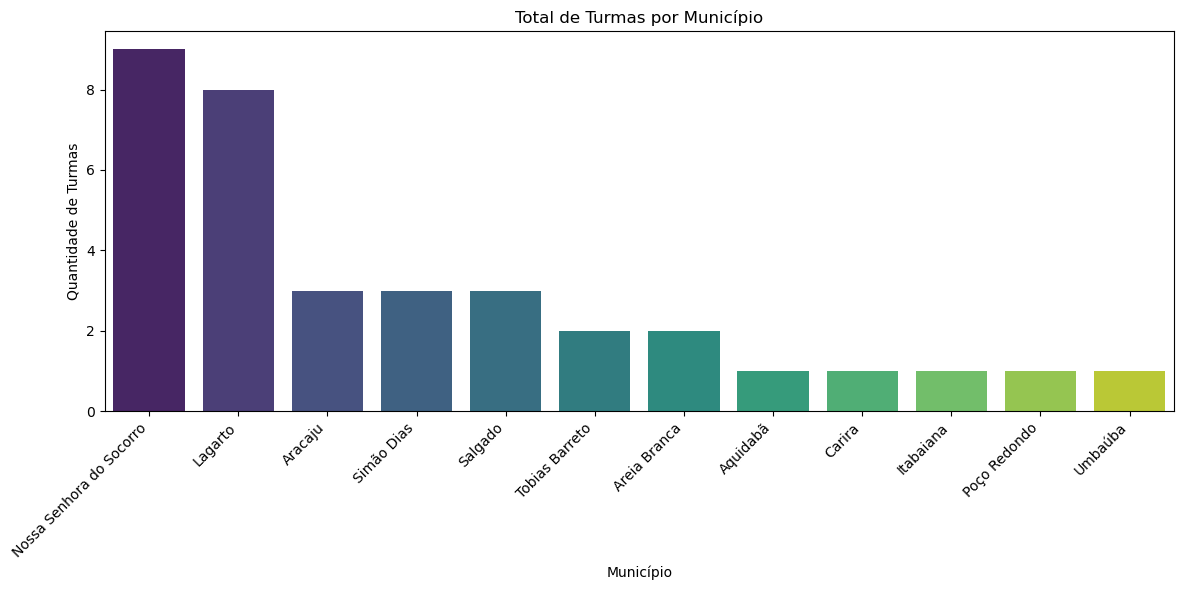

In [15]:
# Criando diretório para salvar os gráficos
output_dir_relatorio_32 = "Data_files/graficos_relatorio_somativa_35_turmas"
os.makedirs(output_dir_relatorio_32, exist_ok=True)

# Criando gráfico de total de turmas por município
plt.figure(figsize=(12, 6))
sns.barplot(data=turmas_por_unidade.sort_values('total_turmas', ascending=False),
            x='municipio',
            y='total_turmas',
            palette='viridis',
            hue='municipio',
            legend=False)
plt.title('Total de Turmas por Município')
plt.xlabel('Município')
plt.ylabel('Quantidade de Turmas')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{output_dir_relatorio_32}/total_por_municipio.png', dpi=300)
plt.show()

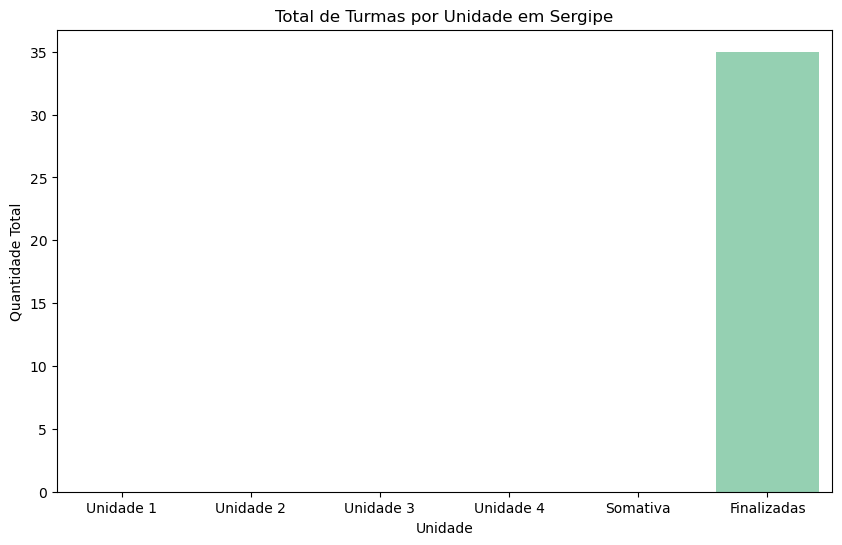

,Unidade,Quantidade
0,Finalizadas,35
1,Somativa,0
2,Unidade 1,0
3,Unidade 2,0
4,Unidade 3,0
5,Unidade 4,0


In [16]:
# Criando gráfico de total de turmas em cada unidade
# Gráfico 2: Total de turmas por unidade (com rótulos personalizados)
df_unidades = turmas_por_unidade.melt(
    id_vars=['municipio'],
    value_vars=['turmas_em_unid_1', 'turmas_em_unid_2', 'turmas_em_unid_3', 'turmas_em_unid_4', 'turmas_em_somativa', 'turmas_finalizadas'],
    var_name='Unidade',
    value_name='Quantidade'
)

# Mapear nomes das unidades
mapeamento_unidades = {
    'turmas_em_unid_1': 'Unidade 1',
    'turmas_em_unid_2': 'Unidade 2',
    'turmas_em_unid_3': 'Unidade 3',
    'turmas_em_unid_4': 'Unidade 4',
    'turmas_em_somativa': 'Somativa',
    'turmas_finalizadas': 'Finalizadas'
}
df_unidades['Unidade'] = df_unidades['Unidade'].map(mapeamento_unidades)

# Plotar o gráfico (sem warnings!)
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_unidades,
    x='Unidade',
    y='Quantidade',
    hue='Unidade',      # Adicionado para evitar o warning
    estimator=sum,
    errorbar=None,
    palette='mako',
    legend=False        # Remove legenda redundante
)
plt.title('Total de Turmas por Unidade em Sergipe')
plt.xlabel('Unidade')
plt.ylabel('Quantidade Total')
plt.savefig(f'{output_dir_relatorio_32}/total_turmas_por_unidade_sergipe.png', dpi=300)
#plt.close()
plt.show()

df_unidades.groupby('Unidade')['Quantidade'].sum().reset_index()

In [17]:
# Criando um gráfico por município para mostrar número de turmas em cada unidade
# Criar um gráfico para cada município
for municipio in turmas_por_unidade['municipio'].unique():
    # Filtrar dados do município
    df_municipio = turmas_por_unidade[turmas_por_unidade['municipio'] == municipio]
    
    # Transformar os dados para formato longo (melt) e aplicar mapeamento
    df_melted = df_municipio.melt(
        id_vars=['municipio'], 
        value_vars=['turmas_em_unid_1', 'turmas_em_unid_2', 'turmas_em_unid_3', 'turmas_em_unid_4', 'turmas_em_somativa'],
        var_name='Unidade', 
        value_name='Quantidade'
    )
    
    # Aplicar os novos nomes das unidades
    df_melted['Unidade'] = df_melted['Unidade'].map(mapeamento_unidades)
    
    # Ordenar as unidades
    df_melted['Unidade'] = pd.Categorical(
        df_melted['Unidade'],
        categories=['Unidade 1', 'Unidade 2', 'Unidade 3', 'Unidade 4', 'Somativa'],
        ordered=True
    )
    
    # Configurar o gráfico (versão atualizada do Seaborn)
    plt.figure(figsize=(8, 5))
    sns.barplot(
        data=df_melted,
        x='Unidade',
        y='Quantidade',
        hue='Unidade',  # Adicionado para evitar o warning
        palette='rocket',
        legend=False    # Não mostra a legenda redundante
    )
    
    # Adicionar título e rótulos
    plt.title(f'Distribuição de Turmas em {municipio}')
    plt.xlabel('Unidade')
    plt.ylabel('Quantidade de Turmas')
    
    # Salvar o gráfico
    nome_arquivo = f"turmas_por_unidade_{municipio.lower().replace(' ', '_').replace('ã', 'a').replace('ç', 'c')}.png"
    plt.tight_layout()
    plt.savefig(f'{output_dir_relatorio_32}/{nome_arquivo}', dpi=300)
    plt.close()


##### Estudando os dados por município
Agora vamos entender os dados de cada município. Dessa forma, nosso objetivo aqui é:
- Entender a quantidade de alunos por município e sua proporção em relação ao programa como um todo;
- Entender a quantidade de turmas por município e sua proporção em relação ao programa como um todo;
- Entender a relevância dos alunos perante o total de alunos enturmados em Sergipe;
- Gerar os resultados dos registros por atividade estruturada por município;
- Gerar os resultados de perfil de turma por município e entender se os perfis são diferentes.

##### Entendendo alunos e turmas por município


#### Atividade Estruturada Formativa 1

Primeiramente, vamos construir uma tabela contando as quantidades de cada nível para cada formativa, considerando a linguagem, municipio e a turma.

In [18]:
# Calculando moda dos níveis para cada linguagem
def calcular_moda_nivel(df, form_number):
    """
    Calcula a moda da coluna 'nivel' para um dataframe de formulário específico.
    
    Args:
        df: DataFrame com os registros do formulário
        form_number: Número do formulário (1, 2, 3, 4 ou 5 para somativa)
    
    Returns:
        DataFrame com as modas calculadas
    """
    moda_df = (
        df.groupby(['cpf', 'nome', 'turma', 'municipio', 'linguagem'])['nivel']
        .agg(lambda x: x.mode().iloc[0])
        .reset_index()
    )
    return moda_df

# Calcular modas para cada formulário
moda_form_1 = calcular_moda_nivel(df_registros_form_1, 1)
moda_form_2 = calcular_moda_nivel(df_registros_form_2, 2)
moda_form_3 = calcular_moda_nivel(df_registros_form_3, 3)
moda_form_4 = calcular_moda_nivel(df_registros_form_4, 4)
moda_somativa = calcular_moda_nivel(df_registros_soma, 5)

# Contando níveis por formativa
def contar_niveis_por_form(df, form_number):
    # Conta a ocorrência de cada nível, mantendo as colunas de agrupamento
    # Adicionando observed=True para evitar o warning
    contagem = (
        df.groupby(['turma', 'municipio', 'linguagem', 'nivel'], observed=True)
        .size()
        .unstack(fill_value=0)
        .reset_index()
    )
    
    # Renomeia as colunas de nível para incluir o número do formulário
    nivel_cols = [col for col in contagem.columns if col not in ['turma', 'municipio', 'linguagem']]
    rename_dict = {col: f'form_{form_number}_{col}' for col in nivel_cols}
    contagem = contagem.rename(columns=rename_dict)
    
    return contagem

# Aplicar a função para cada formulário
contagem_form_1 = contar_niveis_por_form(moda_form_1, 1)
contagem_form_2 = contar_niveis_por_form(moda_form_2, 2)
contagem_form_3 = contar_niveis_por_form(moda_form_3, 3)
contagem_form_4 = contar_niveis_por_form(moda_form_4, 4)
contagem_somativa = contar_niveis_por_form(moda_somativa, 'somativa')  

# Combinar os resultados com outer join
df_contagem_completa = (
    contagem_form_1
    .merge(contagem_form_2, 
           on=['turma', 'municipio', 'linguagem'], 
           how='outer',
           suffixes=('', '_form2'))
    .merge(contagem_form_3, 
           on=['turma', 'municipio', 'linguagem'],
           how='outer',
           suffixes=('', '_form3'))
    .merge(contagem_form_4, 
           on=['turma', 'municipio', 'linguagem'],
           how='outer',
           suffixes=('', '_form4'))
    .merge(contagem_somativa, 
           on=['turma', 'municipio', 'linguagem'],
           how='outer',
           suffixes=('', '_somativa'))
    .fillna(0)
)

# Limpeza final dos nomes das colunas
df_contagem_completa.columns = [col.replace('_form2', '_form_2').replace('_form3', '_form_3').replace('_form4', '_form_4').replace('_form_5', '_somativa') 
                               for col in df_contagem_completa.columns]

# Ordenação final
df_contagem_completa = df_contagem_completa.sort_values(
    by=['turma', 'municipio', 'linguagem']
).reset_index(drop=True)

# Separando por linguagem
#df_analise_linguistica = df_contagem_completa[df_contagem_completa['linguagem'] == 'Análise linguística'].drop(['form_3_Nível 1', 'form_3_Nível 2', 'form_3_Nível 3', 'form_4_Nível 1', 'form_4_Nível 2', 'form_4_Nível 3', 'form_somativa_Nível 1', 'form_somativa_Nível 2', 'form_somativa_Nível 3'], axis=1, errors='ignore').reset_index(drop=True)
#df_oralidade_leitura_13 = df_contagem_completa[df_contagem_completa['linguagem'] == 'Oralidade e leitura'].drop(['form_2_Nível 1', 'form_2_Nível 2', 'form_2_Nível 3', 'form_4_Nível 1', 'form_4_Nível 2', 'form_4_Nível 3', 'form_somativa_Nível 1', 'form_somativa_Nível 2', 'form_somativa_Nível 3'], axis=1, errors='ignore').reset_index(drop=True)
#df_oralidade_leitura_14 = df_contagem_completa[df_contagem_completa['linguagem'] == 'Oralidade e leitura'].drop(['form_2_Nível 1', 'form_2_Nível 2', 'form_2_Nível 3', 'form_3_Nível 1', 'form_3_Nível 2', 'form_3_Nível 3', 'form_somativa_Nível 1', 'form_somativa_Nível 2', 'form_somativa_Nível 3'], axis=1, errors='ignore').reset_index(drop=True)
df_oralidade_leitura_15 = df_contagem_completa[df_contagem_completa['linguagem'] == 'Oralidade e leitura'].drop(['form_2_Nível 1', 'form_2_Nível 2', 'form_2_Nível 3', 'form_3_Nível 1', 'form_3_Nível 2', 'form_3_Nível 3', 'form_4_Nível 1', 'form_4_Nível 2', 'form_4_Nível 3'], axis=1, errors='ignore').reset_index(drop=True)
#df_oralidade_leitura_34 = df_contagem_completa[df_contagem_completa['linguagem'] == 'Oralidade e leitura'].drop(['form_1_Nível 1', 'form_1_Nível 2', 'form_1_Nível 3', 'form_2_Nível 1', 'form_2_Nível 2', 'form_2_Nível 3', 'form_somativa_Nível 1', 'form_somativa_Nível 2', 'form_somativa_Nível 3'], axis=1, errors='ignore').reset_index(drop=True)
#df_oralidade_leitura_35 = df_contagem_completa[df_contagem_completa['linguagem'] == 'Oralidade e leitura'].drop(['form_1_Nível 1', 'form_1_Nível 2', 'form_1_Nível 3', 'form_2_Nível 1', 'form_2_Nível 2', 'form_2_Nível 3', 'form_4_Nível 1', 'form_4_Nível 2', 'form_4_Nível 3'], axis=1, errors='ignore').reset_index(drop=True)
#df_oralidade_leitura_45 = df_contagem_completa[df_contagem_completa['linguagem'] == 'Oralidade e leitura'].drop(['form_1_Nível 1', 'form_1_Nível 2', 'form_1_Nível 3', 'form_2_Nível 1', 'form_2_Nível 2', 'form_2_Nível 3', 'form_3_Nível 1', 'form_3_Nível 2', 'form_3_Nível 3'], axis=1, errors='ignore').reset_index(drop=True)
#df_producao_escrita_34 = df_contagem_completa[df_contagem_completa['linguagem'] == 'Produção escrita'].drop(['form_1_Nível 1', 'form_1_Nível 2', 'form_1_Nível 3', 'form_2_Nível 1', 'form_2_Nível 2', 'form_2_Nível 3', 'form_somativa_Nível 1', 'form_somativa_Nível 2', 'form_somativa_Nível 3'], axis=1, errors='ignore').reset_index(drop=True)
df_producao_escrita_35 = df_contagem_completa[df_contagem_completa['linguagem'] == 'Produção escrita'].drop(['form_1_Nível 1', 'form_1_Nível 2', 'form_1_Nível 3', 'form_2_Nível 1', 'form_2_Nível 2', 'form_2_Nível 3', 'form_4_Nível 1', 'form_4_Nível 2', 'form_4_Nível 3'], axis=1, errors='ignore').reset_index(drop=True)
#df_producao_escrita_45 = df_contagem_completa[df_contagem_completa['linguagem'] == 'Produção escrita'].drop(['form_1_Nível 1', 'form_1_Nível 2', 'form_1_Nível 3', 'form_2_Nível 1', 'form_2_Nível 2', 'form_2_Nível 3', 'form_3_Nível 1', 'form_3_Nível 2', 'form_3_Nível 3'], axis=1, errors='ignore').reset_index(drop=True)

# Contando número total de alunos por turma com base na Formativa 1
#df_analise_linguistica['total_alunos_form_1'] = df_analise_linguistica[['form_1_Nível 1', 'form_1_Nível 2', 'form_1_Nível 3']].sum(axis=1)
#df_analise_linguistica['total_alunos_form_2'] = df_analise_linguistica[['form_2_Nível 1', 'form_2_Nível 2', 'form_2_Nível 3']].sum(axis=1)
#df_oralidade_leitura_13['total_alunos_form_1'] = df_oralidade_leitura_13[['form_1_Nível 1', 'form_1_Nível 2', 'form_1_Nível 3']].sum(axis=1)
#df_oralidade_leitura_13['total_alunos_form_3'] = df_oralidade_leitura_13[['form_3_Nível 1', 'form_3_Nível 2', 'form_3_Nível 3']].sum(axis=1)
#df_oralidade_leitura_14['total_alunos_form_1'] = df_oralidade_leitura_14[['form_1_Nível 1', 'form_1_Nível 2', 'form_1_Nível 3']].sum(axis=1)
#df_oralidade_leitura_14['total_alunos_form_4'] = df_oralidade_leitura_14[['form_4_Nível 1', 'form_4_Nível 2', 'form_4_Nível 3']].sum(axis=1)
df_oralidade_leitura_15['total_alunos_form_1'] = df_oralidade_leitura_15[['form_1_Nível 1', 'form_1_Nível 2', 'form_1_Nível 3']].sum(axis=1)
df_oralidade_leitura_15['total_alunos_form_somativa'] = df_oralidade_leitura_15[['form_somativa_Nível 1', 'form_somativa_Nível 2', 'form_somativa_Nível 3']].sum(axis=1)
#df_oralidade_leitura_34['total_alunos_form_3'] = df_oralidade_leitura_34[['form_3_Nível 1', 'form_3_Nível 2', 'form_3_Nível 3']].sum(axis=1)
#df_oralidade_leitura_34['total_alunos_form_4'] = df_oralidade_leitura_34[['form_4_Nível 1', 'form_4_Nível 2', 'form_4_Nível 3']].sum(axis=1)
#df_oralidade_leitura_35['total_alunos_form_3'] = df_oralidade_leitura_35[['form_3_Nível 1', 'form_3_Nível 2', 'form_3_Nível 3']].sum(axis=1)
#df_oralidade_leitura_35['total_alunos_form_somativa'] = df_oralidade_leitura_35[['form_somativa_Nível 1', 'form_somativa_Nível 2', 'form_somativa_Nível 3']].sum(axis=1)
#df_oralidade_leitura_45['total_alunos_form_4'] = df_oralidade_leitura_45[['form_4_Nível 1', 'form_4_Nível 2', 'form_4_Nível 3']].sum(axis=1)
#df_oralidade_leitura_45['total_alunos_form_somativa'] = df_oralidade_leitura_45[['form_somativa_Nível 1', 'form_somativa_Nível 2', 'form_somativa_Nível 3']].sum(axis=1)
#df_producao_escrita_34['total_alunos_form_3'] = df_producao_escrita_34[['form_3_Nível 1', 'form_3_Nível 2', 'form_3_Nível 3']].sum(axis=1)
#df_producao_escrita_34['total_alunos_form_4'] = df_producao_escrita_34[['form_4_Nível 1', 'form_4_Nível 2', 'form_4_Nível 3']].sum(axis=1)
df_producao_escrita_35['total_alunos_form_3'] = df_producao_escrita_35[['form_3_Nível 1', 'form_3_Nível 2', 'form_3_Nível 3']].sum(axis=1)
df_producao_escrita_35['total_alunos_form_somativa'] = df_producao_escrita_35[['form_somativa_Nível 1', 'form_somativa_Nível 2', 'form_somativa_Nível 3']].sum(axis=1)
#df_producao_escrita_45['total_alunos_form_4'] = df_producao_escrita_45[['form_4_Nível 1', 'form_4_Nível 2', 'form_4_Nível 3']].sum(axis=1)
#df_producao_escrita_45['total_alunos_form_somativa'] = df_producao_escrita_45[['form_somativa_Nível 1', 'form_somativa_Nível 2', 'form_somativa_Nível 3']].sum(axis=1)

# Calcular proporções para cada nível em cada teste
for nivel in ['Nível 1', 'Nível 2', 'Nível 3']:
    #df_analise_linguistica[f'prop_form_1_{nivel}'] = df_analise_linguistica[f'form_1_{nivel}'] / df_analise_linguistica['total_alunos_form_1']
    #df_analise_linguistica[f'prop_form_2_{nivel}'] = df_analise_linguistica[f'form_2_{nivel}'] / df_analise_linguistica['total_alunos_form_2']
    #df_oralidade_leitura_13[f'prop_form_1_{nivel}'] = df_oralidade_leitura_13[f'form_1_{nivel}'] / df_oralidade_leitura_13['total_alunos_form_1']
    #df_oralidade_leitura_13[f'prop_form_3_{nivel}'] = df_oralidade_leitura_13[f'form_3_{nivel}'] / df_oralidade_leitura_13['total_alunos_form_3']
    #df_oralidade_leitura_14[f'prop_form_1_{nivel}'] = df_oralidade_leitura_14[f'form_1_{nivel}'] / df_oralidade_leitura_14['total_alunos_form_4']
    #df_oralidade_leitura_14[f'prop_form_4_{nivel}'] = df_oralidade_leitura_14[f'form_4_{nivel}'] / df_oralidade_leitura_14['total_alunos_form_4']
    df_oralidade_leitura_15[f'prop_form_1_{nivel}'] = df_oralidade_leitura_15[f'form_1_{nivel}'] / df_oralidade_leitura_15['total_alunos_form_somativa']
    df_oralidade_leitura_15[f'prop_form_somativa_{nivel}'] = df_oralidade_leitura_15[f'form_somativa_{nivel}'] / df_oralidade_leitura_15['total_alunos_form_somativa']
    #df_oralidade_leitura_34[f'prop_form_3_{nivel}'] = df_oralidade_leitura_34[f'form_3_{nivel}'] / df_oralidade_leitura_34['total_alunos_form_3']
    #df_oralidade_leitura_34[f'prop_form_4_{nivel}'] = df_oralidade_leitura_34[f'form_4_{nivel}'] / df_oralidade_leitura_34['total_alunos_form_4']
    #df_oralidade_leitura_35[f'prop_form_3_{nivel}'] = df_oralidade_leitura_35[f'form_3_{nivel}'] / df_oralidade_leitura_35['total_alunos_form_3']
    #df_oralidade_leitura_35[f'prop_form_somativa_{nivel}'] = df_oralidade_leitura_35[f'form_somativa_{nivel}'] / df_oralidade_leitura_35['total_alunos_form_somativa']
    #df_oralidade_leitura_45[f'prop_form_4_{nivel}'] = df_oralidade_leitura_45[f'form_4_{nivel}'] / df_oralidade_leitura_45['total_alunos_form_4']
    #df_oralidade_leitura_45[f'prop_form_somativa_{nivel}'] = df_oralidade_leitura_45[f'form_somativa_{nivel}'] / df_oralidade_leitura_45['total_alunos_form_somativa']
    #df_producao_escrita_34[f'prop_form_3_{nivel}'] = df_producao_escrita_34[f'form_3_{nivel}'] / df_producao_escrita_34['total_alunos_form_3']
    #df_producao_escrita_34[f'prop_form_4_{nivel}'] = df_producao_escrita_34[f'form_4_{nivel}'] / df_producao_escrita_34['total_alunos_form_4']
    df_producao_escrita_35[f'prop_form_3_{nivel}'] = df_producao_escrita_35[f'form_3_{nivel}'] / df_producao_escrita_35['total_alunos_form_3']
    df_producao_escrita_35[f'prop_form_somativa_{nivel}'] = df_producao_escrita_35[f'form_somativa_{nivel}'] / df_producao_escrita_35['total_alunos_form_somativa']
    #df_producao_escrita_45[f'prop_form_4_{nivel}'] = df_producao_escrita_45[f'form_4_{nivel}'] / df_producao_escrita_45['total_alunos_form_4']
    #df_producao_escrita_45[f'prop_form_somativa_{nivel}'] = df_producao_escrita_45[f'form_somativa_{nivel}'] / df_producao_escrita_45['total_alunos_form_somativa']
    

In [19]:
# Checando dados NaN no dataframe
#zero_analise_linguistica_form_1 = (df_analise_linguistica['total_alunos_form_1'] == 0).sum()
#zero_analise_linguistica_form_2 = (df_analise_linguistica['total_alunos_form_2'] == 0).sum()
#zero_oralidade_leitura_13_form_1 = (df_oralidade_leitura_13['total_alunos_form_1'] == 0).sum()
#zero_oralidade_leitura_13_form_3 = (df_oralidade_leitura_13['total_alunos_form_3'] == 0).sum()
#zero_oralidade_leitura_14_form_1 = (df_oralidade_leitura_14['total_alunos_form_1'] == 0).sum()
#zero_oralidade_leitura_14_form_4 = (df_oralidade_leitura_14['total_alunos_form_4'] == 0).sum()
zero_oralidade_leitura_15_form_1 = (df_oralidade_leitura_15['total_alunos_form_1'] == 0).sum()
zero_oralidade_leitura_15_form_somativa = (df_oralidade_leitura_15['total_alunos_form_somativa'] == 0).sum()
#zero_oralidade_leitura_34_form_3 = (df_oralidade_leitura_34['total_alunos_form_3'] == 0).sum()
#zero_oralidade_leitura_34_form_4 = (df_oralidade_leitura_34['total_alunos_form_4'] == 0).sum()
#zero_oralidade_leitura_35_form_3 = (df_oralidade_leitura_35['total_alunos_form_3'] == 0).sum()
#zero_oralidade_leitura_35_form_somativa = (df_oralidade_leitura_35['total_alunos_form_somativa'] == 0).sum()
#zero_oralidade_leitura_45_form_4 = (df_oralidade_leitura_45['total_alunos_form_4'] == 0).sum()
#zero_oralidade_leitura_45_form_somativa = (df_oralidade_leitura_45['total_alunos_form_somativa'] == 0).sum()
#zero_producao_escrita_34_form_3 = (df_producao_escrita_34['total_alunos_form_3'] == 0).sum()
#zero_producao_escrita_34_form_4 = (df_producao_escrita_34['total_alunos_form_4'] == 0).sum()
zero_producao_escrita_35_form_3 = (df_producao_escrita_35['total_alunos_form_3'] == 0).sum()
zero_producao_escrita_35_form_somativa = (df_producao_escrita_35['total_alunos_form_somativa'] == 0).sum()
#zero_producao_escrita_45_form_4 = (df_producao_escrita_45['total_alunos_form_4'] == 0).sum()
#zero_producao_escrita_45_form_somativa = (df_producao_escrita_45['total_alunos_form_somativa'] == 0).sum()


# Imprimindo resultados
#print(f"Análise Linguística - Formativa 1 com zero alunos: {zero_analise_linguistica_form_1}")
#print(f"Análise Linguística - Formativa 2 com zero alunos: {zero_analise_linguistica_form_2}")
#print(f"Oralidade e Leitura 13 - Formativa 1 com zero alunos: {zero_oralidade_leitura_13_form_1}")
#print(f"Oralidade e Leitura 13 - Formativa 3 com zero alunos: {zero_oralidade_leitura_13_form_3}")
#print(f"Oralidade e Leitura 14 - Formativa 1 com zero alunos: {zero_oralidade_leitura_14_form_1}")
#print(f"Oralidade e Leitura 14 - Formativa 4 com zero alunos: {zero_oralidade_leitura_14_form_4}")
print(f"Oralidade e Leitura 15 - Formativa 1 com zero alunos: {zero_oralidade_leitura_15_form_1}")
print(f"Oralidade e Leitura 15 - Somativa com zero alunos: {zero_oralidade_leitura_15_form_somativa}")
#print(f"Oralidade e Leitura 34 - Formativa 3 com zero alunos: {zero_oralidade_leitura_34_form_3}")
#print(f"Oralidade e Leitura 34 - Formativa 4 com zero alunos: {zero_oralidade_leitura_34_form_4}")
#print(f"Oralidade e Leitura 35 - Formativa 3 com zero alunos: {zero_oralidade_leitura_35_form_3}")
#print(f"Oralidade e Leitura 35 - Somativa com zero alunos: {zero_oralidade_leitura_35_form_somativa}")
#print(f"Oralidade e Leitura 45 - Formativa 4 com zero alunos: {zero_oralidade_leitura_45_form_4}")
#print(f"Oralidade e Leitura 45 - Somativa com zero alunos: {zero_oralidade_leitura_45_form_somativa}")
#print(f"Produção Escrita 34 - Formativa 3 com zero alunos: {zero_producao_escrita_34_form_3}")
#print(f"Produção Escrita 34 - Formativa 4 com zero alunos: {zero_producao_escrita_34_form_4}")
print(f"Produção Escrita 35 - Formativa 3 com zero alunos: {zero_producao_escrita_35_form_3}")
print(f"Produção Escrita 35 - Somativa com zero alunos: {zero_producao_escrita_35_form_somativa}")
#print(f"Produção Escrita 45 - Formativa 4 com zero alunos: {zero_producao_escrita_45_form_4}")
#print(f"Produção Escrita 45 - Somativa com zero alunos: {zero_producao_escrita_45_form_somativa}")

Oralidade e Leitura 15 - Formativa 1 com zero alunos: 0
Oralidade e Leitura 15 - Somativa com zero alunos: 0
Produção Escrita 35 - Formativa 3 com zero alunos: 0
Produção Escrita 35 - Somativa com zero alunos: 0


In [20]:
# Removendo NaN (turmas que não apresentam todos os dados para comparação)
#df_analise_linguistica = df_analise_linguistica.dropna()
#df_oralidade_leitura_13 = df_oralidade_leitura_13.dropna()
#df_oralidade_leitura_14 = df_oralidade_leitura_14.dropna()
df_oralidade_leitura_15 = df_oralidade_leitura_15.dropna()
#df_oralidade_leitura_34 = df_oralidade_leitura_34.dropna()
#df_oralidade_leitura_35 = df_oralidade_leitura_35.dropna()
#df_oralidade_leitura_45 = df_oralidade_leitura_45.dropna()
#df_producao_escrita_34 = df_producao_escrita_34.dropna()
df_producao_escrita_35 = df_producao_escrita_35.dropna()
#df_producao_escrita_45 = df_producao_escrita_45.dropna()

#### Teste Estatístico

##### Oralidade e Leitura

Agora vamos realizar o mesmo teste estatístico para Oralidade e Leitura e Produção Escrita

In [21]:
# Criando função para análise estatística (Wilcoxon) para o estado de Sergipe
def teste_wilcoxon(df, form_a, form_b, output_dir, df_name):
    # Tradutor de nomes de práticas de linguagem
    label_praticas = {
        'df_analise_linguistica': 'Análise Linguística',
        'df_oralidade_leitura_13':'Oralidade e Leitura',
        'df_oralidade_leitura_14':'Oralidade e Leitura',
        'df_oralidade_leitura_15':'Oralidade e Leitura',
        'df_oralidade_leitura_34':'Oralidade e Leitura',
        'df_oralidade_leitura_35':'Oralidade e Leitura',
        'df_oralidade_leitura_45':'Oralidade e Leitura',
        'df_producao_escrita_34': 'Produção Escrita',
        'df_producao_escrita_35': 'Produção Escrita',
        'df_producao_escrita_45': 'Produção Escrita',
    }
    
    # Tradutor de nomes de formativas
    label_formativas = {
        'form_1': 'Formativa 1',
        'form_2': 'Formativa 2',
        'form_3': 'Formativa 3',
        'form_4': 'Formativa 4',
        'form_somativa': 'Somativa'
        }
    
    # Buscando label no dicinário
    label_a = label_formativas.get(form_a, form_a)
    label_b = label_formativas.get(form_b, form_b)
    label_pratica_correta = label_praticas.get(df_name, df_name)
    
    # 1. Análise para todo o estado
    print(f"\n=== ANÁLISE CONSIDERANDO {label_pratica_correta} ({label_a} E {label_b}) PARA TODO O ESTADO DE SERGIPE ===\n")
    
    # Teste de Wilcoxon para amostras pareadas (comparando as proporções de cada turma)
    for nivel in ['Nível 1', 'Nível 2', 'Nível 3']:
        stat, p = wilcoxon(df[f'prop_{form_a}_{nivel}'], 
                           df[f'prop_{form_b}_{nivel}'])
        print(f"\n{nivel}:")
        print(f"Estatística = {stat:.3f}, p-valor = {p:.4f}")
        if p < 0.05:
            print(f"Há diferença significativa (p < 0.05) nas proporções de {nivel} entre os testes.")
            # Verificar a direção da diferença
            median_diff = (df[f'prop_{form_b}_{nivel}'] - df[f'prop_{form_a}_{nivel}']).median()
            if median_diff > 0:
                print(f"A proporção de alunos no {nivel} AUMENTOU significativamente no teste 2.")
            else:
                print(f"A proporção de alunos no {nivel} DIMINUIU significativamente no teste 2.")
        else:
            print(f"Não há diferença significativa (p ≥ 0.05) nas proporções de {nivel} entre os testes.")
    
    # 2. Análise por município
    print(f"\n=== ANÁLISE CONSIDERANDO {label_pratica_correta} (FORMATIVAS {label_a} E {label_b}) POR MUNICÍPIO ===\n")
    
    for municipio in df['municipio'].unique():
        print(f"\nMunicípio: {municipio}")
        df_municipio = df[df['municipio'] == municipio]
        
        if len(df_municipio) < 3:  # Muito poucas turmas para análise
            print("Número de turmas insuficiente para análise estatística.")
            continue
        
        for nivel in ['Nível 1', 'Nível 2', 'Nível 3']:
            stat, p = wilcoxon(df_municipio[f'prop_{form_a}_{nivel}'], 
                               df_municipio[f'prop_{form_b}_{nivel}'])
            print(f"\n{nivel}:")
            print(f"Estatística = {stat:.3f}, p-valor = {p:.4f}")
            if p < 0.05:
                print(f"Há diferença significativa (p < 0.05) em {municipio}.")
                median_diff = (df_municipio[f'prop_{form_b}_{nivel}'] - df_municipio[f'prop_{form_a}_{nivel}']).median()
                if median_diff > 0:
                    print(f"A proporção de alunos no {nivel} AUMENTOU significativamente no teste 2.")
                else:
                    print(f"A proporção de alunos no {nivel} DIMINUIU significativamente no teste 2.")
            else:
                print(f"Não há diferença significativa (p ≥ 0.05) em {municipio}.")
            
    # 3. Análise de transição entre níveis (para todo o estado)
    print(f"\n=== ANÁLISE DE TRANSIÇÃO ENTRE NÍVEIS PARA {label_pratica_correta} (ESTADO) ===\n")
    
    # Calcular totais estaduais para cada nível
    totais_estado = {
        f'{form_a}_Nível 1': df[f'{form_a}_Nível 1'].sum(),
        f'{form_a}_Nível 2': df[f'{form_a}_Nível 2'].sum(),
        f'{form_a}_Nível 3': df[f'{form_a}_Nível 3'].sum(),
        f'{form_b}_Nível 1': df[f'{form_b}_Nível 1'].sum(),
        f'{form_b}_Nível 2': df[f'{form_b}_Nível 2'].sum(),
        f'{form_b}_Nível 3': df[f'{form_b}_Nível 3'].sum(),
        f'total_{form_a}': df[f'total_alunos_{form_a}'].sum(),
        f'total_{form_b}': df[f'total_alunos_{form_b}'].sum()
    }
    
    # Teste qui-quadrado para tabelas de contingência (comparando distribuição dos níveis)
    print("Teste qui-quadrado para distribuição dos níveis entre form_1 e form_3:")
    
    # Criar tabela de contingência
    contingency_table = np.array([
        [totais_estado[f'{form_a}_Nível 1'], totais_estado[f'{form_a}_Nível 2'], totais_estado[f'{form_a}_Nível 3']],
        [totais_estado[f'{form_b}_Nível 1'], totais_estado[f'{form_b}_Nível 2'], totais_estado[f'{form_b}_Nível 3']]
    ])
    
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    print(f"Qui-quadrado = {chi2:.3f}, p-valor = {p:.4f}")
    if p < 0.05:
        print("Há diferença significativa (p < 0.05) na distribuição dos níveis entre os testes.")
        print("Tabela observada:")
        print(contingency_table)
        print("\nTabela esperada sob a hipótese nula:")
        print(expected.round(1))
        
        # Calcular resíduos padronizados para identificar onde estão as diferenças
        residuals = (contingency_table - expected) / np.sqrt(expected)
        print("\nResíduos padronizados (valores absolutos >2 indicam diferenças significativas):")
        print(residuals.round(2))
    else:
        print("Não há diferença significativa (p ≥ 0.05) na distribuição dos níveis entre os testes.")
    
    plt.figure(figsize=(12, 6))
    
    # Proporções estaduais
    prop_form_a = [totais_estado[f'{form_a}_Nível 1']/totais_estado[f'total_{form_a}'],
                   totais_estado[f'{form_a}_Nível 2']/totais_estado[f'total_{form_a}'],
                   totais_estado[f'{form_a}_Nível 3']/totais_estado[f'total_{form_a}']]
    
    prop_form_b = [totais_estado[f'{form_b}_Nível 1']/totais_estado[f'total_{form_b}'],
                   totais_estado[f'{form_b}_Nível 2']/totais_estado[f'total_{form_b}'],
                   totais_estado[f'{form_b}_Nível 3']/totais_estado[f'total_{form_b}']]
    
    # Calcular erros padrão para cada proporção
    # Para proporções, o erro padrão é sqrt(p*(1-p)/n)
    def calc_erro_proporcao(p, n):
        return np.sqrt(p * (1 - p) / n)
    
    erro_form_a = [calc_erro_proporcao(p, totais_estado[f'total_{form_a}']) for p in prop_form_a]
    erro_form_b = [calc_erro_proporcao(p, totais_estado[f'total_{form_b}']) for p in prop_form_b]
    
    bar_width = 0.35
    index = np.arange(3)
    
    # Criar barras com erro
    bars1 = plt.bar(index, prop_form_a, bar_width, label=label_a, alpha=0.8, color='#1f77b4',
                    yerr=erro_form_a, capsize=5, error_kw={'elinewidth': 1, 'capthick': 1})
    
    bars2 = plt.bar(index + bar_width, prop_form_b, bar_width, label=label_b, alpha=0.8, color='#ff7f0e',
                    yerr=erro_form_b, capsize=5, error_kw={'elinewidth': 1, 'capthick': 1})
                
    # Adicionar valores nas barras
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height + 0.03,  # Adicione um offset de 0.02 (2%)
                    f'{height:.1%}',
                    ha='center', va='bottom', fontsize=10)
            
    #Testar cada nível separadamente com Wilcoxon
    niveis_significativos = []
    for i, nivel in enumerate(['Nível 1', 'Nível 2', 'Nível 3']):
        stat, p_nivel = wilcoxon(df[f'prop_{form_a}_{nivel}'], 
                                df[f'prop_{form_b}_{nivel}'])
        if p_nivel < 0.05:
            niveis_significativos.append(i)
            y_pos = max(prop_form_a[i], prop_form_b[i]) + 0.05
            plt.text(index[i] + bar_width/2, y_pos, '*', 
                    ha='center', va='bottom', fontsize=16, color='red')
            
    # Personalizar
    plt.xlabel('Níveis', fontsize=12)
    plt.ylabel('Proporção de Alunos', fontsize=12)
    plt.title(f'Comparação das Proporções por Nível para {label_pratica_correta} ({label_a} e {label_b})- Estado de Sergipe\n* Diferença estatisticamente significativa (p < 0.05)', fontsize=14)
    plt.xticks(index + bar_width/2, ['Nível 1', 'Nível 2', 'Nível 3'])
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.ylim(0, max(prop_form_a + prop_form_b) + 0.15)  # Ajuste para acomodar as barras de erro
    
    # Salvando gráfico
    plt.savefig(f'{output_dir}/teste_wilcoxon_{df_name}_Sergipe.png', dpi=300)
    
    # Exibindo gráfico
    plt.tight_layout()
    plt.show()
    


=== ANÁLISE CONSIDERANDO Oralidade e Leitura (Formativa 1 E Somativa) PARA TODO O ESTADO DE SERGIPE ===


Nível 1:
Estatística = 2.000, p-valor = 0.0000
Há diferença significativa (p < 0.05) nas proporções de Nível 1 entre os testes.
A proporção de alunos no Nível 1 DIMINUIU significativamente no teste 2.

Nível 2:
Estatística = 71.000, p-valor = 0.0005
Há diferença significativa (p < 0.05) nas proporções de Nível 2 entre os testes.
A proporção de alunos no Nível 2 DIMINUIU significativamente no teste 2.

Nível 3:
Estatística = 45.000, p-valor = 0.0000
Há diferença significativa (p < 0.05) nas proporções de Nível 3 entre os testes.
A proporção de alunos no Nível 3 AUMENTOU significativamente no teste 2.

=== ANÁLISE CONSIDERANDO Oralidade e Leitura (FORMATIVAS Formativa 1 E Somativa) POR MUNICÍPIO ===


Município: Carira
Número de turmas insuficiente para análise estatística.

Município: Aquidabã
Número de turmas insuficiente para análise estatística.

Município: Areia Branca
Número d

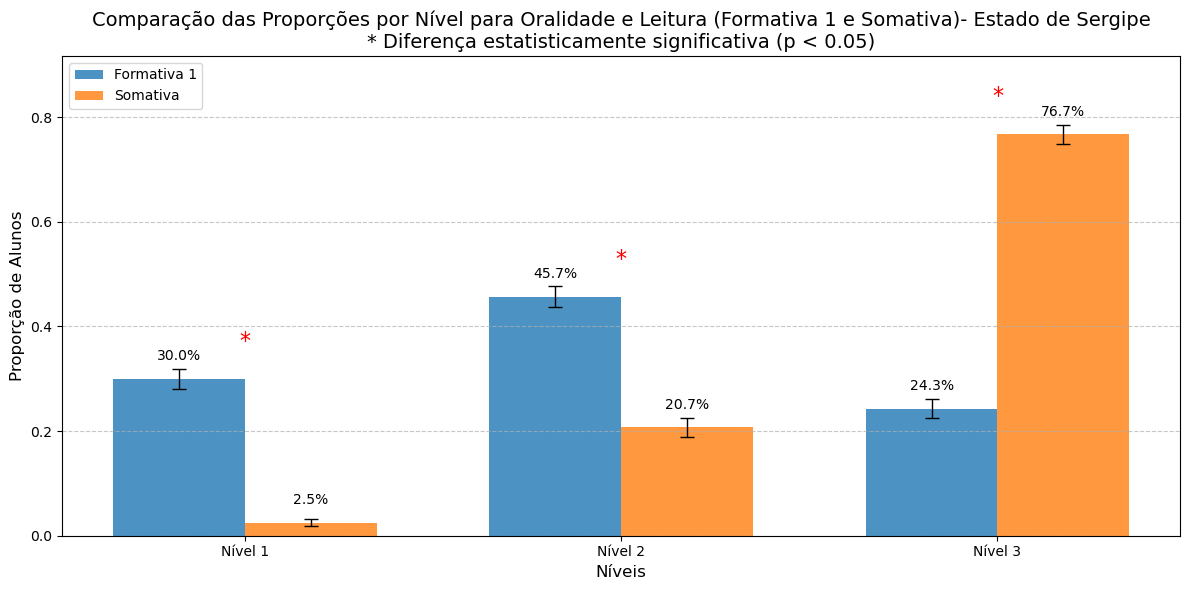

In [22]:
# Aplicando teste de Wilcoxon com função criada
#teste_wilcoxon(df_oralidade_leitura_13, 'form_1', 'form_3', output_dir_relatorio_32, 'df_oralidade_leitura_13')
#teste_wilcoxon(df_oralidade_leitura_14, 'form_1', 'form_4', output_dir_relatorio_32, 'df_oralidade_leitura_14')
teste_wilcoxon(df_oralidade_leitura_15, 'form_1', 'form_somativa', output_dir_relatorio_32, 'df_oralidade_leitura_15')
#teste_wilcoxon(df_oralidade_leitura_34, 'form_3', 'form_4', output_dir_relatorio_32, 'df_oralidade_leitura_34')
#teste_wilcoxon(df_oralidade_leitura_35, 'form_3', 'form_somativa', output_dir_relatorio_32, 'df_oralidade_leitura_35')
#teste_wilcoxon(df_oralidade_leitura_45, 'form_4', 'form_somativa', output_dir_relatorio_32, 'df_oralidade_leitura_45')


In [23]:
# Função para teste de Wilcoxon, criar e salvar gráficos por município
def criar_graficos_municipios(df, form_a, form_b, output_dir, df_name):
    # Agrupar dados por município
    grouped = df.groupby('municipio')
    
    for municipio, group in grouped:
        # Calcular totais para o município
        totais_municipio = {
            f'{form_a}_Nível 1': group[f'{form_a}_Nível 1'].sum(),
            f'{form_a}_Nível 2': group[f'{form_a}_Nível 2'].sum(),
            f'{form_a}_Nível 3': group[f'{form_a}_Nível 3'].sum(),
            f'{form_b}_Nível 1': group[f'{form_b}_Nível 1'].sum(),
            f'{form_b}_Nível 2': group[f'{form_b}_Nível 2'].sum(),
            f'{form_b}_Nível 3': group[f'{form_b}_Nível 3'].sum(),
            f'total_{form_a}': group[f'total_alunos_{form_a}'].sum(),
            f'total_{form_b}': group[f'total_alunos_{form_b}'].sum()
        }
        
        # Calcular proporções
        prop_form_a = [
            totais_municipio[f'{form_a}_Nível 1']/totais_municipio[f'total_{form_a}'],
            totais_municipio[f'{form_a}_Nível 2']/totais_municipio[f'total_{form_a}'],
            totais_municipio[f'{form_a}_Nível 3']/totais_municipio[f'total_{form_a}']
        ]
        
        prop_form_b = [
            totais_municipio[f'{form_b}_Nível 1']/totais_municipio[f'total_{form_b}'],
            totais_municipio[f'{form_b}_Nível 2']/totais_municipio[f'total_{form_b}'],
            totais_municipio[f'{form_b}_Nível 3']/totais_municipio[f'total_{form_b}']
        ]
        
        # Calcular erros padrão
        def calc_erro(p, n):
            return np.sqrt(p * (1 - p) / n) if n > 0 else 0
            
        erro_form_a = [calc_erro(p, totais_municipio[f'total_{form_a}']) for p in prop_form_a]
        erro_form_b = [calc_erro(p, totais_municipio[f'total_{form_b}']) for p in prop_form_b]
        
        # Criar figura
        plt.figure(figsize=(10, 6))
        
        # Configurações do gráfico
        bar_width = 0.35
        index = np.arange(3)
        
        # Tradutor de nomes de práticas de linguagem
        label_praticas = {
            'df_analise_linguistica': 'Análise Linguística',
            'df_oralidade_leitura_13':'Oralidade e Leitura',
            'df_oralidade_leitura_14':'Oralidade e Leitura',
            'df_oralidade_leitura_15':'Oralidade e Leitura',
            'df_oralidade_leitura_34':'Oralidade e Leitura',
            'df_oralidade_leitura_35':'Oralidade e Leitura',
            'df_oralidade_leitura_45':'Oralidade e Leitura',
            'df_producao_escrita_34': 'Produção Escrita',
            'df_producao_escrita_35': 'Produção Escrita',
            'df_producao_escrita_45': 'Produção Escrita'
            }
        
        # Este é o seu "tradutor" de nomes
        label_map = {'form_1': 'Formativa 1',
                     'form_2': 'Formativa 2',
                     'form_3': 'Formativa 3',
                     'form_4': 'Formativa 4',
                     'form_somativa': 'Somativa'
                     }
        
        # Buscando label no dicinário
        label_a = label_map.get(form_a, form_a)
        label_b = label_map.get(form_b, form_b)
        label_pratica_correta = label_praticas.get(df_name, df_name)
        
    
        # Criar barras
        bars1 = plt.bar(index, prop_form_a, bar_width, label=label_a, color='#1f77b4', 
                        yerr=erro_form_a, capsize=5, alpha=0.7)
    
        bars2 = plt.bar(index + bar_width, prop_form_b, bar_width, label=label_b, color='#ff7f0e',
                        yerr=erro_form_b, capsize=5, alpha=0.7)
                
        # Adicionar valores nas barras
        for bars in [bars1, bars2]:
            for bar in bars:
                height = bar.get_height()
                plt.text(bar.get_x() + bar.get_width()/2., height + 0.03,
                         f'{height:.1%}',
                         ha='center', va='bottom', fontsize=9)
        
        # Verificar significância por nível
        niveis_significativos = []
        for i, nivel in enumerate(['Nível 1', 'Nível 2', 'Nível 3']):
            if len(group) >= 3:  # Só testar se tiver turmas suficientes
                stat, p_nivel = wilcoxon(group[f'prop_{form_a}_{nivel}'], 
                                        group[f'prop_{form_b}_{nivel}'])
                if p_nivel < 0.05:
                    niveis_significativos.append(i)
                    y_pos = max(prop_form_a[i], prop_form_b[i]) + 0.05
                    plt.text(index[i] + bar_width/2, y_pos, '*', 
                            ha='center', va='bottom', fontsize=14, color='red')
            
        plt.xlabel('Níveis', fontsize=10)
        plt.ylabel('Proporção de Alunos', fontsize=10)
        plt.title(f'Comparação das Proporções por Nível para {label_pratica_correta} ({label_a} e {label_b}) - {municipio}\n* Diferença estatisticamente significativa (p < 0.05)', fontsize=12)
        plt.xticks(index + bar_width/2, ['Nível 1', 'Nível 2', 'Nível 3'])
        plt.legend()
        plt.grid(axis='y', linestyle='--', alpha=0.5)
        
        # Ajustar layout e salvar
        plt.tight_layout()
        
        # Criar nome do arquivo (substituir caracteres inválidos)
        filename = f"teste_wilcoxon_{df_name}_{municipio.replace(' ', '_').replace('/', '_')}.png"
        filepath = os.path.join(output_dir, filename)
        plt.savefig(filepath, dpi=300, bbox_inches='tight')
        plt.close()
        
        print(f"Gráfico salvo em: {filepath}")


In [24]:
# Chamar a função para criar os gráficos
#criar_graficos_municipios(df_oralidade_leitura_13, 'form_1', 'form_3', output_dir_relatorio_32, 'df_oralidade_leitura_13')
#criar_graficos_municipios(df_oralidade_leitura_14, 'form_1', 'form_4', output_dir_relatorio_32, 'df_oralidade_leitura_14')
criar_graficos_municipios(df_oralidade_leitura_15, 'form_1', 'form_somativa', output_dir_relatorio_32, 'df_oralidade_leitura_15')
#criar_graficos_municipios(df_oralidade_leitura_34, 'form_3', 'form_4', output_dir_relatorio_32, 'df_oralidade_leitura_34')
#criar_graficos_municipios(df_oralidade_leitura_35, 'form_3', 'form_somativa', output_dir_relatorio_32, 'df_oralidade_leitura_35')
#criar_graficos_municipios(df_oralidade_leitura_45, 'form_4', 'form_somativa', output_dir_relatorio_32, 'df_oralidade_leitura_45')


Gráfico salvo em: Data_files/graficos_relatorio_somativa_35_turmas/teste_wilcoxon_df_oralidade_leitura_15_Aquidabã.png
Gráfico salvo em: Data_files/graficos_relatorio_somativa_35_turmas/teste_wilcoxon_df_oralidade_leitura_15_Aracaju.png
Gráfico salvo em: Data_files/graficos_relatorio_somativa_35_turmas/teste_wilcoxon_df_oralidade_leitura_15_Areia_Branca.png
Gráfico salvo em: Data_files/graficos_relatorio_somativa_35_turmas/teste_wilcoxon_df_oralidade_leitura_15_Carira.png
Gráfico salvo em: Data_files/graficos_relatorio_somativa_35_turmas/teste_wilcoxon_df_oralidade_leitura_15_Itabaiana.png
Gráfico salvo em: Data_files/graficos_relatorio_somativa_35_turmas/teste_wilcoxon_df_oralidade_leitura_15_Lagarto.png
Gráfico salvo em: Data_files/graficos_relatorio_somativa_35_turmas/teste_wilcoxon_df_oralidade_leitura_15_Nossa_Senhora_do_Socorro.png
Gráfico salvo em: Data_files/graficos_relatorio_somativa_35_turmas/teste_wilcoxon_df_oralidade_leitura_15_Poço_Redondo.png
Gráfico salvo em: Data_file

##### Produção Escrita

Agora vamos realizar o mesmo teste estatístico para Produção Escrita


=== ANÁLISE CONSIDERANDO Produção Escrita (Formativa 3 E Somativa) PARA TODO O ESTADO DE SERGIPE ===


Nível 1:
Estatística = 9.000, p-valor = 0.0009
Há diferença significativa (p < 0.05) nas proporções de Nível 1 entre os testes.
A proporção de alunos no Nível 1 DIMINUIU significativamente no teste 2.

Nível 2:
Estatística = 42.500, p-valor = 0.0001
Há diferença significativa (p < 0.05) nas proporções de Nível 2 entre os testes.
A proporção de alunos no Nível 2 DIMINUIU significativamente no teste 2.

Nível 3:
Estatística = 9.000, p-valor = 0.0000
Há diferença significativa (p < 0.05) nas proporções de Nível 3 entre os testes.
A proporção de alunos no Nível 3 AUMENTOU significativamente no teste 2.

=== ANÁLISE CONSIDERANDO Produção Escrita (FORMATIVAS Formativa 3 E Somativa) POR MUNICÍPIO ===


Município: Carira
Número de turmas insuficiente para análise estatística.

Município: Aquidabã
Número de turmas insuficiente para análise estatística.

Município: Areia Branca
Número de turma

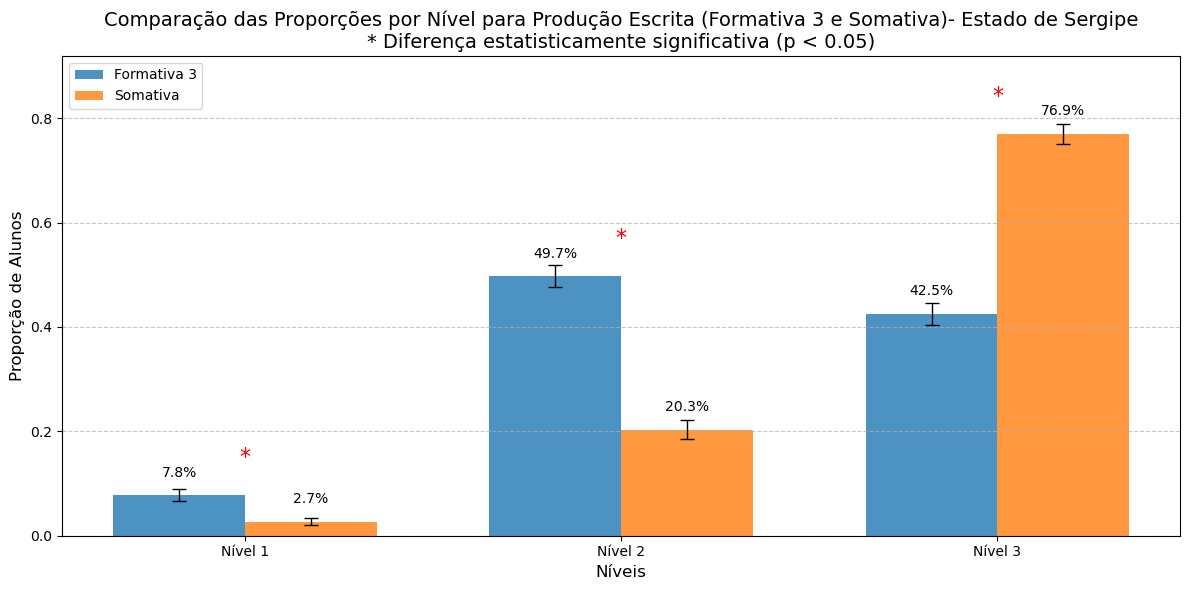

In [25]:
# Aplicando teste de Wilcoxon com função criada para Produção Escrita
#teste_wilcoxon(df_producao_escrita_34, 'form_3', 'form_4', output_dir_relatorio_32, 'df_producao_escrita_34')
teste_wilcoxon(df_producao_escrita_35, 'form_3', 'form_somativa', output_dir_relatorio_32, 'df_producao_escrita_35')
#teste_wilcoxon(df_producao_escrita_45, 'form_4', 'form_somativa', output_dir_relatorio_32, 'df_producao_escrita_45')


In [26]:
# Chamar a função para criar os gráficos de produção escrita para cada municipio
#criar_graficos_municipios(df_producao_escrita_34, 'form_3', 'form_4', output_dir_relatorio_32, 'df_producao_escrita_34')
criar_graficos_municipios(df_producao_escrita_35, 'form_3', 'form_somativa', output_dir_relatorio_32, 'df_producao_escrita_35')
#criar_graficos_municipios(df_producao_escrita_45, 'form_4', 'form_somativa', output_dir_relatorio_32, 'df_producao_escrita_45')

Gráfico salvo em: Data_files/graficos_relatorio_somativa_35_turmas/teste_wilcoxon_df_producao_escrita_35_Aquidabã.png
Gráfico salvo em: Data_files/graficos_relatorio_somativa_35_turmas/teste_wilcoxon_df_producao_escrita_35_Aracaju.png
Gráfico salvo em: Data_files/graficos_relatorio_somativa_35_turmas/teste_wilcoxon_df_producao_escrita_35_Areia_Branca.png
Gráfico salvo em: Data_files/graficos_relatorio_somativa_35_turmas/teste_wilcoxon_df_producao_escrita_35_Carira.png
Gráfico salvo em: Data_files/graficos_relatorio_somativa_35_turmas/teste_wilcoxon_df_producao_escrita_35_Itabaiana.png
Gráfico salvo em: Data_files/graficos_relatorio_somativa_35_turmas/teste_wilcoxon_df_producao_escrita_35_Lagarto.png
Gráfico salvo em: Data_files/graficos_relatorio_somativa_35_turmas/teste_wilcoxon_df_producao_escrita_35_Nossa_Senhora_do_Socorro.png
Gráfico salvo em: Data_files/graficos_relatorio_somativa_35_turmas/teste_wilcoxon_df_producao_escrita_35_Poço_Redondo.png
Gráfico salvo em: Data_files/grafic

In [27]:
# Criando função para calcular proporções de níveis por município
def calcular_proporcoes_municipios(df, form_X, form_Y):
    df_calc = df.groupby('municipio').agg({
        f'{form_X}_Nível 1': 'sum',
        f'{form_X}_Nível 2': 'sum',
        f'{form_X}_Nível 3': 'sum',
        f'{form_Y}_Nível 1': 'sum',
        f'{form_Y}_Nível 2': 'sum',
        f'{form_Y}_Nível 3': 'sum',
        f'total_alunos_{form_X}': 'sum',
        f'total_alunos_{form_Y}': 'sum'
    }).reset_index()
    
    for nivel in ['Nível 1', 'Nível 2', 'Nível 3']:
        df_calc[f'prop_{form_X}_{nivel}'] = 100 * (df_calc[f'{form_X}_{nivel}'] / df_calc[f'total_alunos_{form_X}'])
        df_calc[f'prop_{form_Y}_{nivel}'] = 100 * (df_calc[f'{form_Y}_{nivel}'] / df_calc[f'total_alunos_{form_Y}'])
        
    # Mantendo somente as colunas de proporções
    df_prop = df_calc[['municipio', f'prop_{form_X}_Nível 1', f'prop_{form_X}_Nível 2', f'prop_{form_X}_Nível 3',
                               f'prop_{form_Y}_Nível 1', f'prop_{form_Y}_Nível 2', f'prop_{form_Y}_Nível 3']]
    return df_prop
    
# Calculando proporções por município para Produção Escrita (Formativas 3 e 4) e Oralidade e Leitura (Formativas 1 e 4)
#df_prop_producao_escrita_34 = calcular_proporcoes_municipios(df_producao_escrita_34, 'form_3', 'form_4')
#df_prop_oralidade_leitura_14 = calcular_proporcoes_municipios(df_oralidade_leitura_14, 'form_1', 'form_4')
df_prop_producao_escrita_35 = calcular_proporcoes_municipios(df_producao_escrita_35, 'form_3', 'form_somativa')
df_prop_oralidade_leitura_15 = calcular_proporcoes_municipios(df_oralidade_leitura_15, 'form_1', 'form_somativa')

# Imprimindo resultados
#df_prop_oralidade_leitura_14
#df_prop_producao_escrita_34
#df_prop_oralidade_leitura_15
df_prop_producao_escrita_35


,municipio,prop_form_3_Nível 1,prop_form_3_Nível 2,prop_form_3_Nível 3,prop_form_somativa_Nível 1,prop_form_somativa_Nível 2,prop_form_somativa_Nível 3
0,Aquidabã,0.000000,100.000000,0.000000,0.000000,0.000000,100.000000
1,Aracaju,7.317073,36.585366,56.097561,2.631579,23.684211,73.684211
2,Areia Branca,0.000000,0.000000,100.000000,0.000000,0.000000,100.000000
3,Carira,0.000000,85.714286,14.285714,0.000000,0.000000,100.000000
4,Itabaiana,0.000000,70.000000,30.000000,0.000000,0.000000,100.000000
5,Lagarto,9.016393,58.196721,32.786885,0.000000,17.094017,82.905983
6,Nossa Senhora do Socorro,4.724409,51.968504,43.307087,1.694915,22.033898,76.271186
7,Poço Redondo,0.000000,25.000000,75.000000,5.263158,31.578947,63.157895
8,Salgado,2.272727,36.363636,61.363636,2.380952,16.666667,80.952381
9,Simão Dias,14.814815,68.518519,16.666667,10.714286,30.357143,58.928571


### Análise de relatório de Somativa

In [28]:
# Dicionário com os títulos descritivos
titulos_perguntas = {
    'pergunta_1': '1. Quanto à motivação e interesse, a turma participou das atividades\ne aplicou o que aprende no dia a dia com:',
    'pergunta_2': '2. Quanto à autonomia e responsabilidade (independência, organização e\npontualidade), os(as) alfabetizandos(as) demonstraram:',
    'pergunta_3': '3. Os(as) alfabetizandos(as) lidaram com medos e inseguranças em relação ao erro:',
    'pergunta_4': '4. Os(as) alfabetizandos(as) demonstraram capacidade de persistir\ndiante de desafios e frustrações:',
    'pergunta_5': '5. A turma de alfabetizandos(as) apresentou nível de interação\ncom colegas e alfabetizador(a):',
    'pergunta_6': '6. Com relação ao desenvolvimento das habilidades de leitura, escrita\ne compreensão de textos, a turma demonstrou:',
    'pergunta_7': '7. Observou-se que os(as) alfabetizandos(as) utilizaram o aprendizado na vida prática:',
    'pergunta_8': '8. Quanto a valorização do saber os(a) alfabetizandos(a) demostraram:',
    'pergunta_9': '9. Quanto às habilidades de leitura e escrita, você considera que sua turma concluiu no:'
}

# Função para quebrar textos longos
def quebrar_texto(texto, max_length=15):
    if pd.isna(texto):
        return texto
    return '\n'.join(textwrap.wrap(str(texto), width=max_length))

# Configurações iniciais
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14

# 1. Preparação dos dados (igual ao anterior)
analise_perguntas = pd.DataFrame()
for pergunta in [f'pergunta_{i}' for i in range(1, 10)]:
    contagem = df_relatorios_somativa[pergunta].value_counts().reset_index()
    contagem.columns = ['resposta', 'contagem']
    contagem['porcentagem'] = (contagem['contagem'] / contagem['contagem'].sum()) * 100
    contagem['pergunta'] = pergunta
    contagem['resposta_formatada'] = contagem['resposta'].apply(quebrar_texto)
    analise_perguntas = pd.concat([analise_perguntas, contagem])

# 2. Gerar e salvar gráficos em arquivos separados
for file_num in range(5):
    fig, axes = plt.subplots(1, 2, figsize=(22, 12))
    plt.subplots_adjust(wspace=0.4, hspace=0.5)
    
    start_idx = file_num * 2
    end_idx = start_idx + 2
    
    # Gera a lista de perguntas para este arquivo (ex: pergunta_9 e pergunta_10)
    lista_perguntas_arquivo = [f'pergunta_{j}' for j in range(start_idx+1, end_idx+1)]
    
    for i, pergunta in enumerate(lista_perguntas_arquivo):
        # Verificar se a pergunta existe antes de plotar
        if pergunta not in titulos_perguntas or pergunta not in analise_perguntas['pergunta'].values:
            axes[i].set_visible(False) # Oculta o gráfico vazio (ex: pergunta_10)
            continue # Pula para o próximo loop
        
        dados = analise_perguntas[analise_perguntas['pergunta'] == pergunta].sort_values('porcentagem', ascending=False)
        
        if dados.empty: # Segurança caso não haja respostas para a pergunta
             axes[i].set_visible(False)
             continue
        
        # Gráfico Seaborn - REMOVER RÓTULOS DO EIXO X
        ax = sns.barplot(
            data=dados,
            x='resposta_formatada',
            y='porcentagem',
            hue='resposta_formatada',
            palette='viridis',
            dodge=False,
            ax=axes[i],
            legend=False
        )
        
        # Remover rótulos do eixo X
        ax.set_xticklabels([])
        ax.set_xlabel('')
        
        # Títulos e labels
        ax.set_title(titulos_perguntas[pergunta], fontsize=18, pad=25)
        ax.set_ylabel('Porcentagem (%)', fontsize=14)
        
        # Ajustar eixo y
        ax.set_ylim(0, min(100, dados['porcentagem'].max() * 1.2))
        sns.despine(left=True)
        
        # Adicionar valores nas barras
        for p in ax.patches:
            ax.annotate(
                f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 8),
                textcoords='offset points',
                fontsize=14
            )
        
        # CRIAR LEGENDA NA ÁREA VAZIA
        handles = [plt.Rectangle((0,0),1,1, color=color) for color in sns.color_palette("viridis", len(dados))]
        ax.legend(
            handles=handles,
            labels=list(dados['resposta_formatada']),
            title='Respostas',
            bbox_to_anchor=(0.9, 0.9),  # Posição relativa ao gráfico
            loc='upper left',
            borderaxespad=0.,
            frameon=True,
            fontsize=14,
            title_fontsize=16
        )
        
        ax.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Salvar figura
    output_path = os.path.join(output_dir_relatorio_32, f'graficos_relatorio_soma_{file_num+1}.png')
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.close()

print(f"✅ Gráficos salvos em: {os.path.abspath(output_dir_relatorio_32)}")
analise_perguntas.sort_values(['pergunta', 'porcentagem'], ascending=[True, False])


✅ Gráficos salvos em: /home/fabcmc/GitHub Files/FGV/pba_se_2025/Data_files/graficos_relatorio_somativa_35_turmas


,resposta,contagem,porcentagem,pergunta,resposta_formatada
0,Alto interesse,31,88.571429,pergunta_1,Alto interesse
1,Interesse moderado,4,11.428571,pergunta_1,Interesse\nmoderado
0,Total autonomia,23,65.714286,pergunta_2,Total autonomia
1,Autonomia parcial,11,31.428571,pergunta_2,Autonomia\nparcial
2,Precisou de apoio,1,2.857143,pergunta_2,Precisou de\napoio
0,Alguma insegurança,19,54.285714,pergunta_3,Alguma\ninsegurança
1,Enfrentaram bem,15,42.857143,pergunta_3,Enfrentaram bem
2,Muita insegurança\ne resiliência,1,2.857143,pergunta_3,Muita\ninsegurança e\nresiliência
0,Com grande resiliência,27,77.142857,pergunta_4,Com grande\nresiliência
1,Com resiliência moderada,7,20.000000,pergunta_4,Com resiliência\nmoderada
